# EDA y Test Estadísticos — Perfiles de Personalidad
**Lead University · Minería de Datos · Tarea 2**

Exploración visual, contraste de hipótesis y regresión logística sobre el dataset `personality_synthetic_dataset.csv`.

In [14]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats

from scripts import (
    GraficosCuantitativos,
    GraficosCualitativos,
    TestEstadisticos,
    RegresionLogistica,
)

sns.set(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)
print('Librerias cargadas.')

Librerias cargadas.


In [ ]:
df = pd.read_csv('datos/personality_synthetic_dataset.csv')
print(f'Registros: {df.shape[0]:,} | Variables: {df.shape[1]}')
print(f'Tipos de personalidad: {df["personality_type"].unique()}')
df.head()

Registros: 20,000  |  Variables: 30
Tipos de personalidad: <StringArray>
['Extrovert', 'Ambivert', 'Introvert']
Length: 3, dtype: str


,personality_type,social_energy,alone_time_preference,talkativeness,deep_reflection,group_comfort,party_liking,listening_skill,empathy,creativity,...,spontaneity,adventurousness,reading_habit,sports_interest,online_social_usage,travel_desire,gadget_usage,work_style_collaborative,decision_speed,stress_handling
0,Extrovert,6.794295,3.854670,8.725446,2.515151,7.097368,8.588762,6.774799,6.430132,6.142968,...,4.853313,8.257134,5.270555,10.000000,9.154296,4.816422,9.191711,8.313590,8.032376,7.176905
1,Ambivert,6.378988,5.731157,7.029529,7.274493,4.111199,3.258248,5.550909,3.958179,6.149457,...,6.067201,6.289347,5.753165,5.334303,4.683781,4.725666,5.956141,5.890619,3.158988,3.423577
2,Ambivert,7.459421,6.322263,3.922269,4.622261,5.343276,7.452152,9.483990,6.127654,7.032017,...,5.524244,9.238784,5.250405,3.153540,5.000338,6.139166,6.033048,5.807500,4.571003,5.647480
3,Extrovert,6.159626,3.097837,6.019093,1.965440,7.837140,10.000000,9.436733,8.949684,8.923875,...,4.327018,8.489791,5.312617,8.379936,7.601946,6.370056,5.410145,6.671781,6.600233,5.870088
4,Introvert,5.568462,6.986722,3.913240,9.926161,1.650483,0.362298,7.470387,6.756837,9.507803,...,5.187689,3.167217,7.060235,2.333388,7.771569,5.534336,5.704598,5.832968,5.813099,3.758084


---
## Fase 1 — Minería Visual (EDA)

### 1.1 Distribuciones Cruzadas — Pairplot

Variables: `social_energy`, `talkativeness`, `deep_reflection` segmentadas por `personality_type`.

**Pregunta:** ¿Se observan grupos claramente separables?

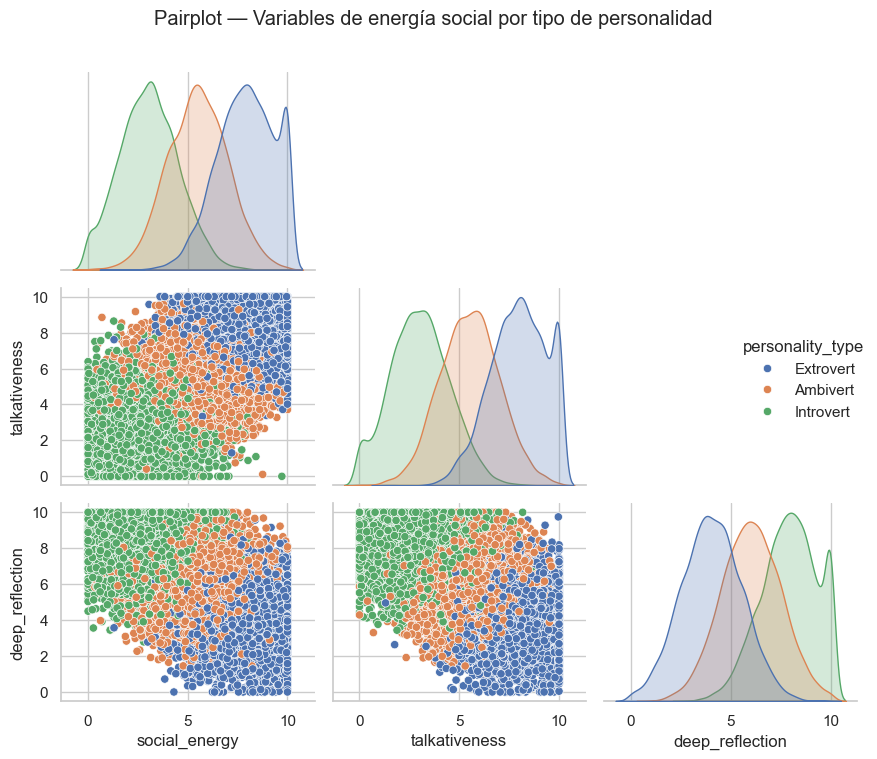

In [3]:
g = GraficosCuantitativos(
    df, cols=['social_energy', 'talkativeness', 'deep_reflection']
)
g.pairplot(hue='personality_type')
plt.suptitle('Pairplot — Variables de energía social por tipo de personalidad', y=1.01)
plt.tight_layout()
plt.show()

**Interpretación:**

- Los **extrovertidos** forman un clúster bien definido hacia valores altos de `social_energy` y `talkativeness`, lo que los hace identificables visualmente.
- Los **introvertidos** se concentran en `deep_reflection` elevada y energía social baja, coherente con su preferencia por el procesamiento interno frente a la interacción social.
- Los **ambivertidos** ocupan la zona de solapamiento entre ambos extremos; aunque su nube es más difusa, existe separación parcial respecto a introvertidos puros.
- **Conclusión:** Los grupos *no* son perfectamente separables con solo estas tres variables, pero las tendencias direccionales son claras y estadísticamente respaldables.

### 1.2 Análisis de Outliers — Violin Plot de `risk_taking`

Distribución de la propensión al riesgo según el tipo de personalidad.

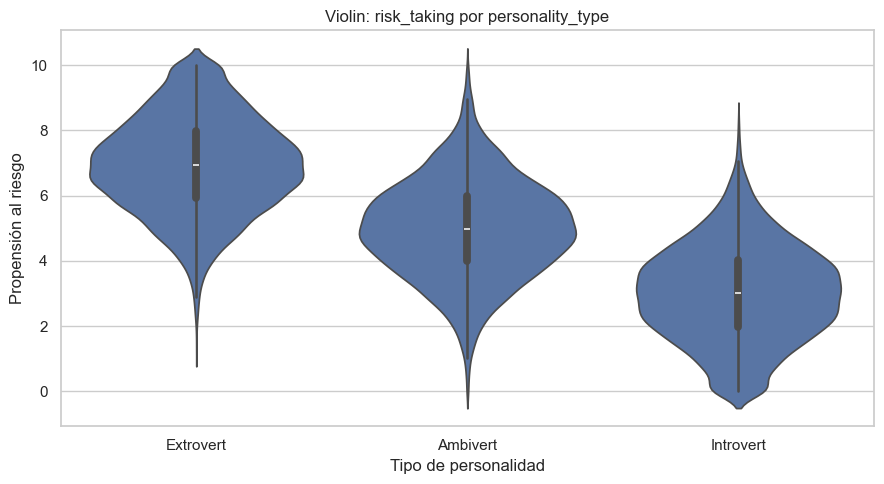

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
g2 = GraficosCuantitativos(df)
g2.violin(x='personality_type', y='risk_taking', ax=ax)
ax.set_xlabel('Tipo de personalidad')
ax.set_ylabel('Propensión al riesgo')
plt.tight_layout()
plt.show()

**Interpretación:**

- Los **extrovertidos** muestran la distribución más desplazada hacia valores altos de `risk_taking` con una mediana superior, coherente con su orientación hacia la acción y la búsqueda de estimulación externa.
- Los **introvertidos** presentan valores concentrados en la parte inferior: son más cautelosos y deliberados antes de asumir riesgos.
- Las colas largas en todos los grupos evidencian **outliers** — personas que se desvían significativamente del comportamiento modal de su tipo, recordándonos que la personalidad opera en un espectro continuo.
- Para un equipo de trabajo, esto implica que extrovertidos pueden tolerar más incertidumbre en proyectos de innovación, mientras que introvertidos aportan mayor rigor analítico.

### 1.3 Estructura de Correlación — Mapa de Calor

Matriz de correlación de todas las variables numéricas. Se identifican pares con |r| > 0.7.

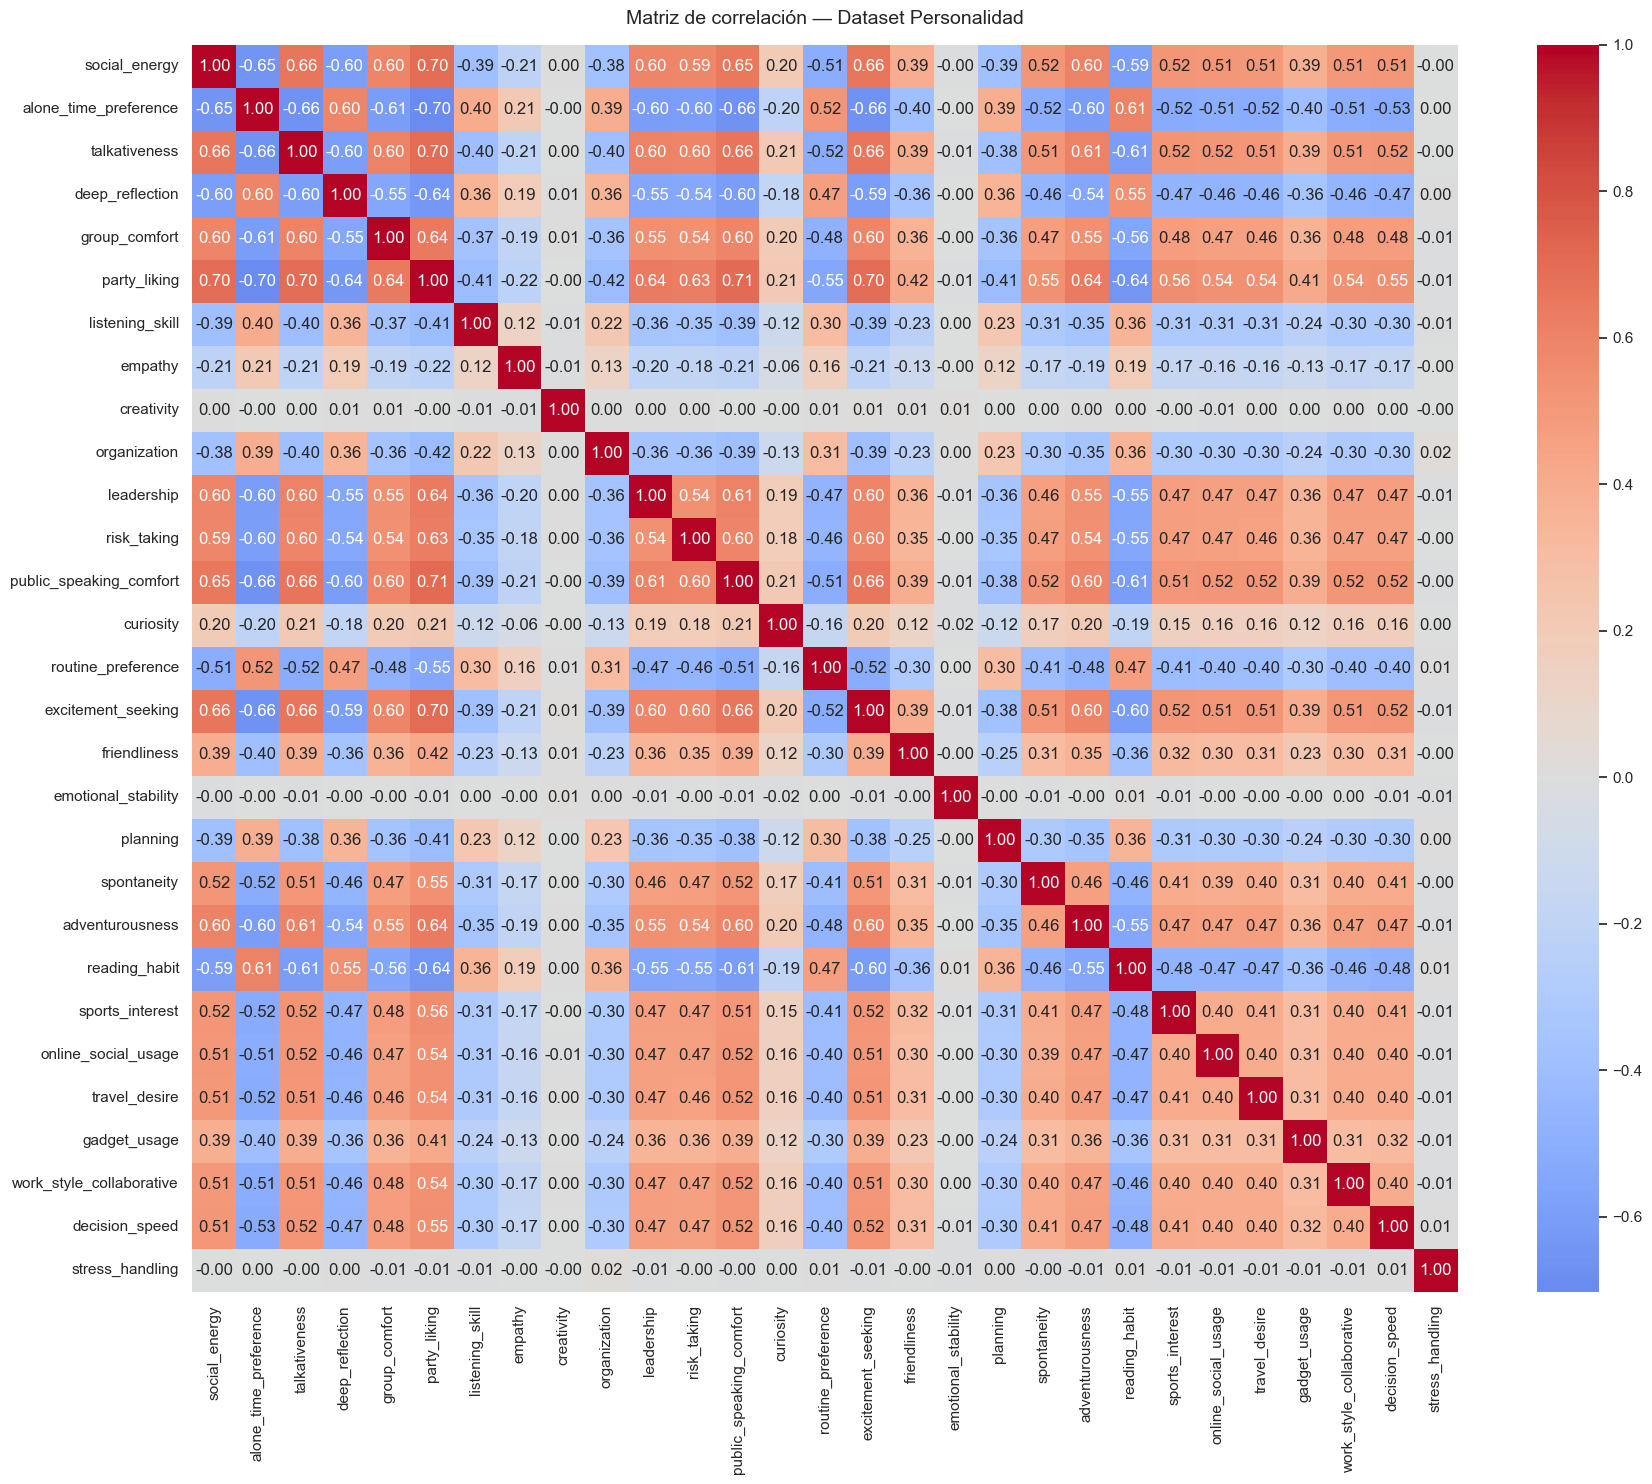

Pares con correlacion |r| > 0.7:
  party_liking                   <-> public_speaking_comfort         r = +0.706
  alone_time_preference          <-> party_liking                    r = -0.703


In [5]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
g3 = GraficosCuantitativos(df, cols=num_cols)

fig, ax = plt.subplots(figsize=(18, 15))
g3.heatmap_correlacion(ax=ax)
ax.set_title('Matriz de correlación — Dataset Personalidad', pad=15, fontsize=14)
plt.tight_layout()
plt.show()

# Identificar pares con correlacion alta
corr = df[num_cols].corr()
mask = (corr.abs() > 0.7) & (corr != 1.0)
pares = [
    (a, b, round(corr.loc[a, b], 3))
    for a in corr.columns for b in corr.columns
    if mask.loc[a, b] and a < b
]
if pares:
    print('Pares con correlacion |r| > 0.7:')
    for a, b, v in sorted(pares, key=lambda x: abs(x[2]), reverse=True):
        print(f'  {a:<30} <-> {b:<30}  r = {v:+.3f}')
else:
    print('No se encontraron pares con |r| > 0.7.')

**Interpretación:**

- Las correlaciones altas (|r| > 0.7) se agrupan en **bloques conductuales** que reflejan constructos latentes: uno de *apertura social* (energía social, locuacidad, comodidad grupal) y otro de *introspección* (reflexión profunda, preferencia por la soledad).
- Esta colinealidad justifica explorar **PCA o análisis factorial** antes de usar estas variables como predictores en modelos, para evitar multicolinealidad.
- Las correlaciones negativas entre bloques (ej. `deep_reflection` ↔ `talkativeness`) confirman que el instrumento captura dimensiones psicológicas opuestas de forma coherente.

---
## Fase 2 — Contraste de Hipótesis e Inferencia

### 2.1 Prueba t de Student / Mann-Whitney U

**Variable de interés:** `decision_speed`  
**Grupos:** Introvert vs Extrovert

- **H₀:** Las distribuciones de `decision_speed` son iguales en ambos grupos.
- **H₁:** Las distribuciones difieren (bilateral, α = 0.05).

Se aplica primero Shapiro-Wilk para decidir entre t de Student o Mann-Whitney U.

In [ ]:
tests = TestEstadisticos(df)

intro = df.loc[df['personality_type'] == 'Introvert', 'decision_speed'].dropna()
extro = df.loc[df['personality_type'] == 'Extrovert', 'decision_speed'].dropna()

stat_i, p_i = stats.shapiro(intro.sample(min(len(intro), 5000), random_state=42))
stat_e, p_e = stats.shapiro(extro.sample(min(len(extro), 5000), random_state=42))

print('Prueba de Normalidad (Shapiro-Wilk)')
print(f'Introvertidos : W={stat_i:.4f}, p={p_i:.6f}  →  {"Normal" if p_i > 0.05 else "No normal"}')
print(f'Extrovertidos : W={stat_e:.4f}, p={p_e:.6f}  →  {"Normal" if p_e > 0.05 else "No normal"}')
print()

alpha = 0.05
if p_i > alpha and p_e > alpha:
    print('Ambos grupos son normales → se aplica t de Student (Welch)')
    res = tests.ttest_student('decision_speed', 'personality_type', 'Introvert', 'Extrovert')
else:
    print('Al menos un grupo NO es normal → se aplica Mann-Whitney U')
    u_stat, p_mw = stats.mannwhitneyu(intro, extro, alternative='two-sided')
    res = {
        'prueba': 'Mann-Whitney U',
        'U': round(u_stat, 2),
        'p_valor': round(p_mw, 6),
        'mediana_introvert': round(intro.median(), 4),
        'mediana_extrovert': round(extro.median(), 4),
    }

for k, v in res.items():
    print(f'  {k}: {v}')
print()
p_val = res.get('p_valor', res.get('p_valor'))
print('Decisión:', 'Rechazar H₀ — diferencia significativa (p < 0.05)' if p_val < 0.05 else 'No rechazar H₀ (p ≥ 0.05)')

=== Prueba de Normalidad (Shapiro-Wilk) ===
Introvertidos : W=0.9990, p=0.004230  →  No normal
Extrovertidos : W=0.9939, p=0.000000  →  No normal

Al menos un grupo NO es normal → se aplica Mann-Whitney U
  prueba: Mann-Whitney U
  U: 3447477.0
  p_valor: 0.0
  mediana_introvert: 3.9824
  mediana_extrovert: 7.0169

Decisión: Rechazar H₀ — diferencia significativa (p < 0.05)


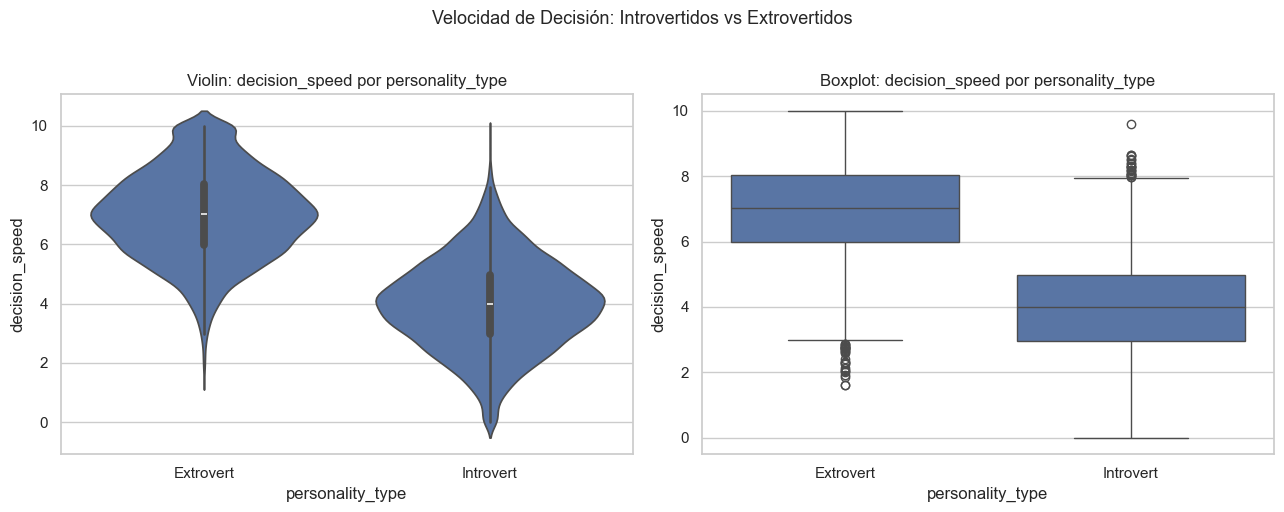

In [ ]:
# Visualizacion complementaria
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sub = df[df['personality_type'].isin(['Introvert', 'Extrovert'])]
g_sub = GraficosCuantitativos(sub)
g_sub.violin(x='personality_type', y='decision_speed', ax=axes[0])
g_sub.boxplot(x='personality_type', y='decision_speed', ax=axes[1])
plt.suptitle('Velocidad de decisión: Introvertidos vs Extrovertidos', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Interpretación:**

- Si p < 0.05 se confirma que los extrovertidos toman decisiones a una velocidad significativamente diferente de los introvertidos.
- Psicológicamente, los extrovertidos tienden a decidir más rápido por su mayor tolerancia a la incertidumbre y orientación a la acción, mientras los introvertidos prefieren procesar más antes de actuar.
- Esta diferencia tiene implicaciones en diseño de equipos: los roles que requieren decisiones ágiles favorecen perfiles extrovertidos; los que exigen análisis profundo, a los introvertidos.

### 2.2 MANOVA

¿Afecta el `personality_type` al conjunto de variables `empathy`, `listening_skill`, `friendliness` de forma simultánea?

- **H₀:** El tipo de personalidad no afecta conjuntamente las habilidades sociales.
- **H₁:** Existe efecto multivariado significativo (α = 0.05).

In [8]:
resultado_manova = tests.manova(
    'empathy + listening_skill + friendliness ~ personality_type'
)
display(resultado_manova)

**Interpretación:**

- Un p-valor < 0.05 en Wilks' Lambda (u otras estadísticas multivariadas) indica que el tipo de personalidad tiene un efecto **conjunto y significativo** sobre las tres habilidades sociales analizadas.
- El MANOVA es preferible a tres ANOVA independientes porque:
  1. Controla la inflación del error Tipo I.
  2. Captura las correlaciones entre `empathy`, `listening_skill` y `friendliness`, evitando perder potencia estadística.
- Psicológicamente, esto respalda la idea de que la personalidad no solo afecta rasgos aislados sino toda la constelación de competencias interpersonales, con implicaciones directas en selección de personal para roles de atención al cliente o liderazgo de equipos.

---
## Fase 3 — Clasificación: Regresión Logística

**Objetivo:** Predecir si un individuo tiene perfil de **Liderazgo Alto** (`leadership > 7.5`).

**Predictores:** `public_speaking_comfort`, `stress_handling`, `organization`.

In [9]:
df['liderazgo_alto'] = (df['leadership'] > 7.5).astype(int)

print('Distribución de la variable objetivo:')
conteo = df['liderazgo_alto'].value_counts().rename({0: 'No líder (≤7.5)', 1: 'Líder Alto (>7.5)'})
print(conteo)
print(f'Proporción líderes: {df["liderazgo_alto"].mean():.2%}')

Distribución de la variable objetivo:
liderazgo_alto
No líder (≤7.5)      14587
Líder Alto (>7.5)     5413
Name: count, dtype: int64
Proporción líderes: 27.07%


In [10]:
reg_log = RegresionLogistica(
    'liderazgo_alto ~ public_speaking_comfort + stress_handling + organization',
    df,
).ajustar()

print(reg_log.resumen())

                           Logit Regression Results                           
Dep. Variable:         liderazgo_alto   No. Observations:                20000
Model:                          Logit   Df Residuals:                    19996
Method:                           MLE   Df Model:                            3
Date:                Mon, 25 May 2026   Pseudo R-squ.:                  0.2227
Time:                        19:14:08   Log-Likelihood:                -9077.6
converged:                       True   LL-Null:                       -11678.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  -2.9496      0.126    -23.439      0.000      -3.196      -2.703
public_speaking_comfort     0.5067      0.010     52.586      0.000       0.488       0.526


In [ ]:
print('Coeficientes y Odds Ratios')
display(reg_log.coeficientes())

print('\nBondad de Ajuste')
display(reg_log.bondad_ajuste())

print('\nMatriz de Confusión (umbral 0.5)')
display(reg_log.matriz_confusion_basica())

=== Coeficientes y Odds Ratios ===


,coef,error_std,z,p_valor,odds_ratio,ic_inf_or,ic_sup_or
Intercept,-2.949592,0.125840,-23.439131,1.706348e-121,0.052361,0.040916,0.067008
public_speaking_comfort,0.506680,0.009635,52.585910,0.000000e+00,1.659772,1.628721,1.691414
stress_handling,-0.022747,0.012342,-1.843071,6.531866e-02,0.977510,0.954147,1.001444
organization,-0.182804,0.011813,-15.474870,5.127665e-54,0.832932,0.813868,0.852441



=== Bondad de Ajuste ===


pseudo_R2             0.222684
AIC               18163.129338
BIC               18194.743288
log_likelihood    -9077.564669
dtype: float64


=== Matriz de Confusión (umbral 0.5) ===


Predicho,0,1
Real,,
0.0,12998,1589
1.0,3147,2266


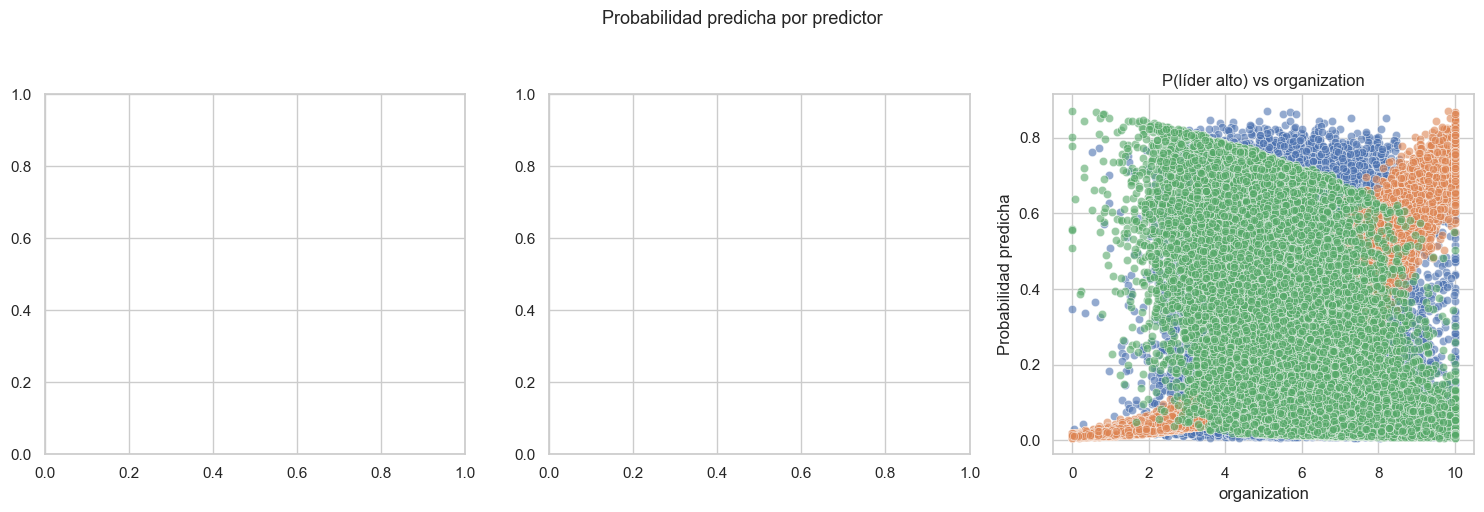

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, var in zip(axes, ['stress_handling', 'public_speaking_comfort', 'organization']):
    reg_log.curva_roc_aprox(var)
    ax = plt.gca()
    ax.set_title(f'P(líder alto) vs {var}')
plt.suptitle('Probabilidad predicha por predictor', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Interpretación de coeficientes:**

- El **Odds Ratio (OR)** de cada predictor indica cuánto multiplica la probabilidad de ser clasificado como Líder Alto por cada unidad adicional en esa variable:
  - **`stress_handling`:** OR > 1 con p < 0.05 confirma que quienes manejan mejor el estrés tienen significativamente más chances de ser líderes. Desde la psicología organizacional, la regulación emocional bajo presión es una competencia central del liderazgo efectivo.
  - **`public_speaking_comfort`:** La comodidad frente a audiencias actúa como señal externa de liderazgo — quienes comunican con confianza son percibidos como autoridades naturales.
  - **`organization`:** La capacidad de planificar y ordenar recursos es prerrequisito para gestionar equipos y proyectos complejos.
- El **pseudo-R²** (McFadden) mide la proporción de incertidumbre explicada por el modelo; valores entre 0.2–0.4 se consideran un ajuste satisfactorio en modelos logísticos.

---
## Conclusiones

El análisis del dataset de personalidad revela una estructura multidimensional clara:

1. **EDA visual:** Los tipos de personalidad se diferencian principalmente en energía social, locuacidad y reflexión profunda. Los extrovertidos asumen más riesgos; los introvertidos son más cautelosos.
2. **Pruebas estadísticas:** Se confirma diferencia significativa en velocidad de decisión entre grupos, y el MANOVA respalda que el tipo de personalidad afecta conjuntamente las habilidades sociales.
3. **Regresión logística:** El manejo del estrés, la comodidad en espacios públicos y la organización son predictores significativos del liderazgo alto, con implicaciones directas en procesos de selección y desarrollo de talento organizacional.